# Solving Stiff ODEs for Real World Applications 
Benjamin Prince (bdp2294), Salma Zobaa (sz22566), James Anthony (jma6474)

## Introduction

In this analysis we will be simulating the behavior of a heat exchanger using cooling by forced convection. The example that we will be simulating here is the cooling system in an internal combustion engine. This system consists of a coolant fluid flowing around the radiator, absorbing its heat before itself being cooled by forced convection as air blown over it removes the heat inside of the coolant from the system. The governing ODE for cooling by forced convection is dx/dt=-h(T-Tambient), with h being the convection coefficient, T being the current temperature, and Tambient being the ambient temperature which will vary with time. A high convection coefficient means that the system will reach thermal equillibrium rapidly, while a low convection coefficient means that the cooling process will occur slowly. For this simulation we will be using the given parameters h=1000s^-1, Tambient=300+50sin(.01t) Kelvin, T(0)= 500 Kelvin. This system is important to understanding the behavior of heat management systems which are critical to the success of engineering systems across disciplines and industries, as it describes how effective a system is at reaching thermal equillibrium.

## Demonstration of Stiffness

### Euler's Forward

<ipython-input-3-a3c62c77f7ee>:16: RuntimeWarning: overflow encountered in double_scalars
  dy_dt=-lam*y_values[j]+lam*(300+50*np.sin(m*t[j])) #Calculate derivative for the current time step
<ipython-input-3-a3c62c77f7ee>:17: RuntimeWarning: invalid value encountered in double_scalars
  y_values[j+1]=y_values[j]+h*dy_dt
/opt/conda/lib/python3.8/site-packages/IPython/core/pylabtools.py:128: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


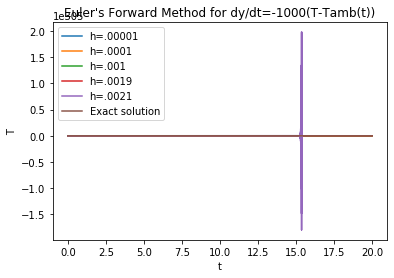

In [3]:
import numpy as np
import matplotlib.pyplot as plt
t_exact=np.arange(0,20.01,.01)
T_0=500 #Kelvin
analytical=300-300*np.exp(-1000*t_exact)+50*np.sin(.01*t_exact)-.0005*np.cos(.01*t_exact)+np.exp(-1000*t_exact)*(.0005+T_0)
string=np.array(["h=.00001","h=.0001", "h=.001", "h=.0019","h=.0021","h=.02"])

h_array=np.array([.00001, .0001,.001,.0019,.0021]) #Create array of h values
def Eulers_Forward(h_array,T_0,lam,m,string):
    for i in range (0,h_array.size): #loop through step sizes
        h=h_array[i]
        t=np.arange(0,20+h,h)#Create array of t values
        y_values=np.zeros(t.size) #Create array of y values
        y_values[0]=T_0
        for j in range (0,t.size-1): #Implement Euler's Forward
            dy_dt=-lam*y_values[j]+lam*(300+50*np.sin(m*t[j])) #Calculate derivative for the current time step
            y_values[j+1]=y_values[j]+h*dy_dt
        plt.plot(t, y_values, label=string[i])
Eulers_Forward(h_array,T_0,1000,.01,string)
plt.plot(t_exact, analytical, label="Exact solution")
plt.title("Euler's Forward Method for dy/dt=-1000(T-Tamb(t))")
plt.xlabel("t")
plt.ylabel("T")
plt.legend()
plt.show()
        

### Instability Demonstrated

This plot demonstrates that the threshold for a good approximation of this system is .002, with h values after that becoming unstable and losing accuracy quickly. This means that to run a good approximation using Euler's forward for this system will require the use of very small step sizes especially if the aim is to simulate the system over any significant time interval.  

### Next Step

Now that the instability of the Euler's forward method has been demonstrated, it must be determined on what values the stability of the system depends. This diffeq is of the form dy/dt=λy+g(t), so the only question now is does the stability depend solely on the ratio of λ to h or does it also depend on the speed at which the function g(t) varies, as it is said that the slowly varying g(t) is part of what makes this system stiff. What I will do in the following section is explore different values of λ and analyze the ratios between lambda and h, then I will vary the speed at which g(t) varies and analyze how this affects the h value at which the method becomes unstable.

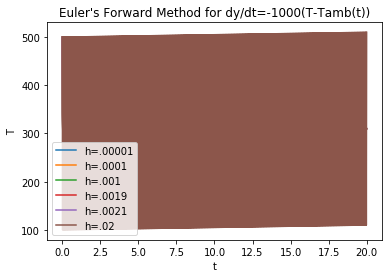

In [4]:
#λ is changed to -100, g(t) still varies by .01t
h_array=np.array([.00001, .0001,.001,.0019,.0021,.02])
Eulers_Forward(h_array,T_0,100,.01,string)
plt.title("Euler's Forward Method for dy/dt=-1000(T-Tamb(t))")
plt.xlabel("t")
plt.ylabel("T")
plt.legend()
plt.show()

The system now blows up at h=.02 rather than at h=.002 as in the original system. Decreasing |λ| by a factor of 10 led to an increase in the viable step size by a factor of ten indicating that |λ| is inversely proportional to the upper bound of h. In this case when the system decayed h*λ=-2.

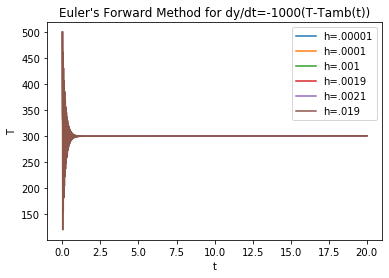

In [5]:
#Holding λ constant and slowing down g(t) by a factor of 10
string=np.array(["h=.00001","h=.0001", "h=.001", "h=.0019","h=.0021","h=.019"])
h_array=np.array([.00001, .0001,.001,.0019,.0021,.019])
Eulers_Forward(h_array,T_0,100,.001,string)
plt.title("Euler's Forward Method for dy/dt=-1000(T-Tamb(t))")
plt.xlabel("t")
plt.ylabel("T")
plt.legend()
plt.show()

In this case, slowing down g(t) by a factor of ten from .01t to .001t did not cause the system to blow up any sooner, and values up to the threshold of .02 are still stable.

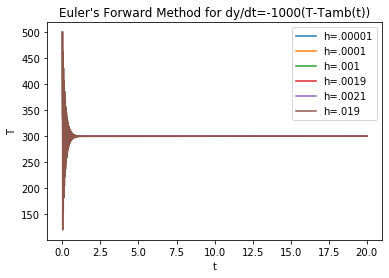

In [6]:
h_array=np.array([.00001, .0001,.001,.0019,.0021,.019])
Eulers_Forward(h_array,T_0,100,.0001,string)
plt.title("Euler's Forward Method for dy/dt=-1000(T-Tamb(t))")
plt.xlabel("t")
plt.ylabel("T")
plt.legend()
plt.show()

The same result is repeated slowing down g(t) another factor of ten. This indicates no relationship between slowing down the oscillation of g(t) and the stability of the approximation. Therefore, the relationship governing stability must be between h and λ alone.

### Stiffness Caluculation Using Eigenvalue

In order to calculate stability I will be looking at what values of h cause y_n+h*dy/dt to coverge to a steady value. The experimentation done above demonstrated that this value of h is proportional only to the λ coefficient in the governing ODE. Now we have only to formulate the exact relationship between the two. First, consider that if λ is positive then for any value of h, the equation will be unstable. This is because the difference between the current T and ambient T term will be magnified by dy/dt will having the same sign as the difference, thus making this difference larger when Euler's method is applied. Therefore we can say that a stable approximation must have h*λ<0. Earlier we discovered that the approximation blew up around h*λ=-2, but in order to explain why that is we need to look at Euler's method for this system: y_n+1=y_n+h(λ(y_n-T_ambient). Substituting in h*λ=-2 and subtracting y_n on both sides gives y_n+1-y_n=-2(y_n-T_ambient), revealing the reason why h*λ=-2 is the point of instability. Because the difference between y_n+1 and y_n will never be smaller than twice the difference between T_ambient and y_n, y_n+1 will be exactly the same distance away from T_ambient as y_n, never converging. Therefore h*λ>-2 is another necessary condition for convergence. Combining these two conditions into 0>h*λ>-2 and adding one to all terms gives 1>1+h*λ>-1, and applying absolute value bars to simplify the expression gives |1+h*λ|<1. This is the condition for the stability of Euler's Forward Method done on this system as demonstrated above.

### Computational Burden

In [7]:
print(20/.002) #Minimum steps required for a convergent approximation simulating 20 seconds

10000.0


Due to the high convection coefficient combined with a slowly varying ambient temperature which acts as a forcing function, this system is stiff. This means that explicit methods require very small step sizes in order to converge. Because such small step sizes are needed, the runtime for Euler's method is high and unnecessarily wastes computational resources. Implicit methods on the other hand will converge for large h values which can save computational resources on stiff stystems like these.

### Newton Raphson Mathematical Setup

g(T_n+1)=T_n+1-T_n-h*(-1000(T_n+1-(300+50sin(.01(t+h)))))=0

Taking the derivative in y; Tn is a constant and vanishes; g(t) is constant in y and vanishes:
g'(T_n+1)=1+1000*h 

Newton Raphson Update Formula:
T_iteration=T_guess-g(T_guess)/g'(T_guess)



## Newton Raphson Implementation

<ipython-input-10-3d4ed6fdfbc2>:19: RuntimeWarning: overflow encountered in double_scalars
  return -h_val * (T - T_ambient(t))
<ipython-input-10-3d4ed6fdfbc2>:44: RuntimeWarning: invalid value encountered in double_scalars
  y_values[i] = y_values[i-1] + h * f(t_values[i-1], y_values[i-1])


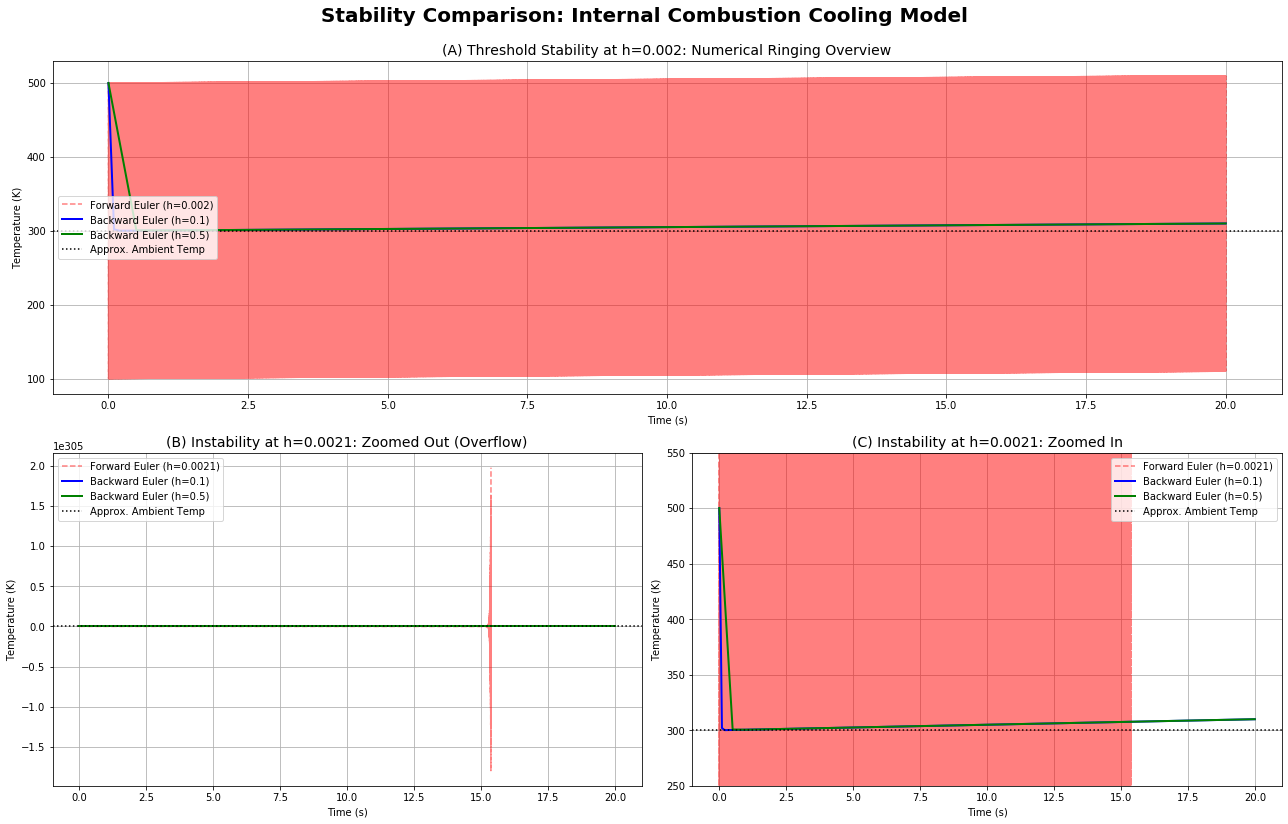

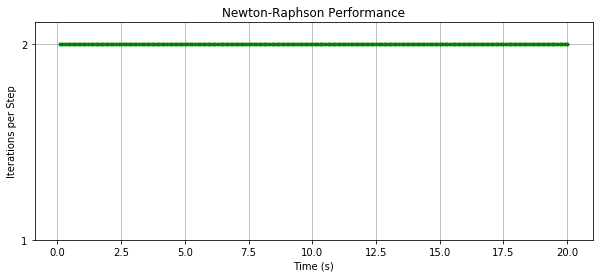

Forward Euler Steps (h = 0.0021): 9525
Forward Euler Steps (h = 0.002): 10001
Backward Euler Steps (h = 0.1): 201
Backward Euler Steps (h = 0.5): 41


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# -------- IMPLEMENTATION ---------

# --- Problem Parameters ---
h_val = 1000.0    # Convection coefficient (stiffness)
T0 = 500.0        # Initial temperature (Kelvin)
t0 = 0.0          # Simulation start time
tf = 20.0         # Simulation end time

# --- Temperature Functions ---
def T_ambient(t):
    # Time-varying ambient temperature formula
    return 300 + 50 * np.sin(0.01 * t)

def f(t, T):
    # Governing ODE: dT/dt = -h(T - Tamb)
    return -h_val * (T - T_ambient(t))

def f_derivative_T(T):
    # Partial derivative of f with respect to T (df/dT)
    return -h_val

# --- Numerical Solvers ---
def newton_raphson(g, dg, x0, tol=1e-6, max_iter=50):
    # Standard Newton-Raphson root-finding loop
    x = x0 # Set initial guess
    for i in range(max_iter):
        x_new = x - g(x) / dg(x) # Apply NR update formula
        if abs(x_new - x) < tol:
            return x_new, i + 1 # Return result and iteration count
        x = x_new # Update guess for next iteration
    return None, max_iter # Return if max iterations reached

def forward_euler(f, y0, t0, tf, h):
    # Explicit method: y_new = y + h * f(t, y)
    t_values = np.arange(t0, tf + h, h) # Create time grid
    y_values = np.zeros_like(t_values)   # Pre-allocate results array
    y_values[0] = y0                    # Apply initial condition
    
    for i in range(1, len(t_values)):
        # Calculate next step using current slope
        y_values[i] = y_values[i-1] + h * f(t_values[i-1], y_values[i-1])
    return t_values, y_values

def backward_euler_with_nr(f, y0, t0, tf, h):
    # Implicit method solved via Newton-Raphson
    t_values = np.arange(t0, tf + h, h) # Create time grid
    y_values = np.zeros_like(t_values)   # Pre-allocate results array
    y_values[0] = y0                    # Apply initial condition
    iterations_log = []                 # List to track NR efficiency
    
    for i in range(1, len(t_values)):
        t_next = t_values[i]
        T_prev = y_values[i-1] # Temperature from previous step
        
        # Define residual function g: T_next - T_prev - h * f = 0
        g = lambda T_next: T_next - T_prev - h * f(t_next, T_next)
        
        # Define derivative: g' = 1 - h * (df/dT)
        dg = lambda T_next: 1 + h_val * h
        
        # Use NR to solve the implicit equation for T_next
        T_next_val, iters = newton_raphson(g, dg, x0=T_prev)
        
        y_values[i] = T_next_val      # Store solved temperature
        iterations_log.append(iters)  # Log how many NR steps it took
        
    return t_values, y_values, iterations_log

# ------------ RESULTS AND ANALYSIS ------------------

h_unstable_ring = 0.002
h_unstable_blow = 0.0021
h_stable_01 = 0.1
h_stable_05 = 0.5

t_fe_ring, T_fe_ring = forward_euler(f, T0, t0, tf, h_unstable_ring)
t_fe_blow, T_fe_blow = forward_euler(f, T0, t0, tf, h_unstable_blow)

t_be_01, T_be_01, _ = backward_euler_with_nr(f, T0, t0, tf, h_stable_01)
t_be_05, T_be_05, _ = backward_euler_with_nr(f, T0, t0, tf, h_stable_05)

fig = plt.figure(figsize=(18, 12))

# overall title
fig.suptitle('Stability Comparison: Internal Combustion Cooling Model', fontsize=20, fontweight='bold')

ax1 = plt.subplot2grid((2, 2), (0, 0), colspan=2)
ax2 = plt.subplot2grid((2, 2), (1, 0))
ax3 = plt.subplot2grid((2, 2), (1, 1))

# Plot 1: Threshold Stability
ax1.plot(t_fe_ring, T_fe_ring, 'r--', alpha=0.5, label='Forward Euler (h=0.002)')
ax1.plot(t_be_01, T_be_01, 'b-', linewidth=2, label='Backward Euler (h=0.1)')
ax1.plot(t_be_05, T_be_05, 'g-', linewidth=2, label='Backward Euler (h=0.5)')
ax1.axhline(300, color='k', linestyle=':', label='Approx. Ambient Temp')
ax1.set_title('(A) Threshold Stability at h=0.002: Numerical Ringing Overview', fontsize=14)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Temperature (K)')
ax1.legend()
ax1.grid(True)

# Plot 2: Absolute Instability Zoomed Out
ax2.plot(t_fe_blow, T_fe_blow, 'r--', alpha=0.5, label='Forward Euler (h=0.0021)')
ax2.plot(t_be_01, T_be_01, 'b-', linewidth=2, label='Backward Euler (h=0.1)')
ax2.plot(t_be_05, T_be_05, 'g-', linewidth=2, label='Backward Euler (h=0.5)')
ax2.axhline(300, color='k', linestyle=':', label='Approx. Ambient Temp')
ax2.set_title('(B) Instability at h=0.0021: Zoomed Out (Overflow)', fontsize=14)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Temperature (K)')
ax2.legend()
ax2.grid(True)

# Plot 3: Absolute Instability Zoomed In
ax3.plot(t_fe_blow, T_fe_blow, 'r--', alpha=0.5, label='Forward Euler (h=0.0021)')
ax3.plot(t_be_01, T_be_01, 'b-', linewidth=2, label='Backward Euler (h=0.1)')
ax3.plot(t_be_05, T_be_05, 'g-', linewidth=2, label='Backward Euler (h=0.5)')
ax3.axhline(300, color='k', linestyle=':', label='Approx. Ambient Temp')
ax3.set_title('(C) Instability at h=0.0021: Zoomed In', fontsize=14)
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Temperature (K)')
ax3.set_ylim(250, 550)
ax3.legend()
ax3.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(t_be[1:], nr_iters, 'go-', markersize=3)
plt.title('Newton-Raphson Performance')
plt.xlabel('Time (s)')
plt.ylabel('Iterations per Step')
plt.yticks([1, 2])
plt.grid(True)
plt.show()

print(f"Forward Euler Steps (h = 0.0021): {len(t_fe_blow)}")
print(f"Forward Euler Steps (h = 0.002): {len(t_fe_ring)}")
print(f"Backward Euler Steps (h = 0.1): {len(t_be_01)}")
print(f"Backward Euler Steps (h = 0.5): {len(t_be_05)}")

### Part 4: Stability Analysis and Comparison


4a: Step Size Comparison
Method            | Max Stable Step Size
---------------------------------------------
Euler Forward     | 0.002 s
Euler Backward    | 0.1 s (stable)
Euler Backward    | 0.05 s (stable)
Euler Backward    | 0.01 s (stable)

4b: Accuracy vs. Computational Cost

Euler Forward (stable h = 0.002 )
 Total steps: 10001
 NR iterations per step: N/A
 Total function evaluations: 10001

Euler Backward h = 0.1
 Total steps: 200
Euler Backward h = 0.05
 Total steps: 400
Euler Backward h = 0.01
 Total steps: 2000
 Average NR iterations per step: 2.0
 Total function evaluations: 4002



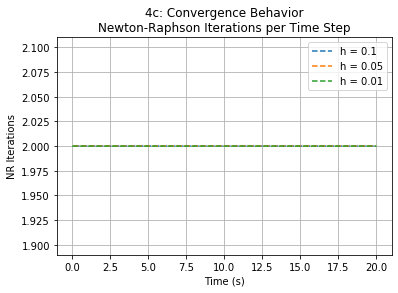

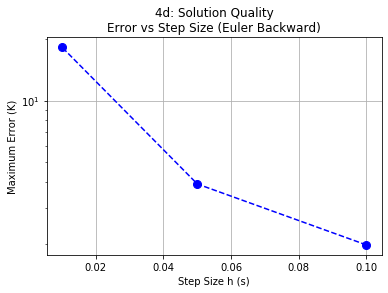

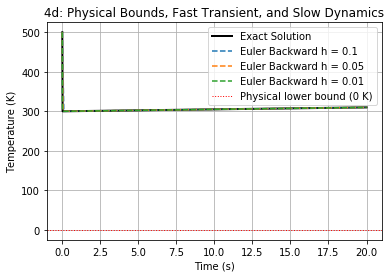

h = 0.1 | Min temperature: 300.1191 K |Physically valid: True
h = 0.05 | Min temperature: 300.076 K |Physically valid: True
h = 0.01 | Min temperature: 300.0257 K |Physically valid: True


In [9]:

#-----Part 4: Stability Analysis and Comparison----

h_list = [0.1, 0.05, 0.01]
h_forward_stable = 0.002

# 4a: Step Size Comparison — Table

print()
print("4a: Step Size Comparison")
print("=" * 45)
print("Method            | Max Stable Step Size")
print("-" * 45)
print("Euler Forward     |", h_forward_stable, "s")
for h in h_list:
    print("Euler Backward    |", h, "s (stable)")
print("=" * 45)

# 4b: Accuracy vs. Computational Cost

t_fe, T_fe = forward_euler(f, T0, t0, tf, h_forward_stable)

print()
print("4b: Accuracy vs. Computational Cost")
print()
print("Euler Forward (stable h =", h_forward_stable, ")")
print(" Total steps:", len(t_fe))
print(" NR iterations per step: N/A")
print(" Total function evaluations:", len(t_fe))
print()
for h in h_list:
    t_b, T_b, iters = backward_euler_with_nr(f, T0, t0, tf, h)
    steps = int((tf- t0) / h)
    avg_iters = round(np.mean(iters), 2)
    total_evals = int(np.sum(iters))
    print("Euler Backward h =", h)
    print(" Total steps:", steps)
print(" Average NR iterations per step:", avg_iters)
print(" Total function evaluations:", total_evals)
print()


# 4c: Convergence Behavior — Plot NR iterations vs time

plt.figure()
for h in h_list:
    t_b, T_b, iters = backward_euler_with_nr(f, T0, t0, tf, h)
    plt.plot(t_b[1:], iters, '--', label="h = " + str(h))
plt.title("4c: Convergence Behavior\nNewton-Raphson Iterations per Time Step")
plt.xlabel("Time (s)")
plt.ylabel("NR Iterations")
plt.legend()
plt.grid(True)
plt.show()


# 4d: Solution Quality — Error plot + physical bounds check

errors = []
for h in h_list:
    t_b, T_b, _ = backward_euler_with_nr(f, T0, t0, tf, h)
    T_ref = exact_solution(t_b)
    errors.append(np.max(np.abs(T_b- T_ref)))
    
plt.figure()
plt.semilogy(h_list, errors, 'bo--', markersize=8)
plt.title("4d: Solution Quality\nError vs Step Size (Euler Backward)")
plt.xlabel("Step Size h (s)")
plt.ylabel("Maximum Error (K)")
plt.grid(True)
plt.show()

t_fine       = np.linspace(t0, tf, 1000)
T_exact_fine = exact_solution(t_fine)

plt.figure()
plt.plot(t_fine, T_exact_fine, 'k-', linewidth=2, label="Exact Solution")
for h in h_list:
    t_b, T_b, _ = backward_euler_with_nr(f, T0, t0, tf, h)
    plt.plot(t_b, T_b, '--', linewidth=1.5, label="Euler Backward h = " + str(h))
plt.axhline(0, color='red', linestyle=':', linewidth=1, label="Physical lower bound (0 K)")
plt.title("4d: Physical Bounds, Fast Transient, and Slow Dynamics")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (K)")
plt.legend()
plt.grid(True)
plt.show()

for h in h_list:
    t_b, T_b, _ = backward_euler_with_nr(f, T0, t0, tf, h)
    print("h =", h, "| Min temperature:", round(np.min(T_b), 4), "K |Physically valid:", np.min(T_b) >= 0)

## Section 5: Results and Analysis

--- Step Size Stability Comparison ---

Theoretically, the maximum stable step size for Euler's Forward method is 0.002, which is found through the stability condition that 'h' must be less than 2/lambda, with lambda equaling 1000. As for Euler's Backward method, it is theorized that it is unconditionally stable regardless of the step size, thus theoretically infinite possible step sizes. As seen in plot C under the stability comparison plots, even when increasing the step size for Euler's Backward method, the method still remained stable and accurate, and did not stray violently from the approximated ambient temperature.

While Forward Euler takes approximately 9,525 steps at h = 0.0021, the simulation is unstable. To reach the stability threshold defined in the mathematical setup, a minimum of 10,000 steps (h </= 0.002) is required. In contrast, the implicit Backward Euler method remains perfectly stable and accurate with only 201 steps (h = 0.1), representing a massive reduction in computational burden.

--- Stability Comparison Plots ---

Across all step sizes, the Backward Euler method remains perfectly stable and follows the expected cooling curve even with step sizes 250 times larger than the explicit limit. As for Forward Euler, in plot A it can be seen that at the threshold of h = 0.002 that it fails to converge but does not immediately explode. The temperature is represented by constant oscillations because the error is flipped by exactly -1 at each step. It does not blow up to infinity but it does not settle down to the correct answer either. This plot does not accurately represent real life cooling thus the conclusion that the model is still a failure. Taking a look at both plots B and C where h = 0.0021 for Euler Forward, it can be seen that the temperature modeling oscillates even more than before because the error grows by 10% after each step. The numbers for temperature became so large that they broke the scale of the graph. This proves that the mathematical derivation of h = 0.002 being the absolute stable size was correct as the model did not explode to infinity, but showcases the weakness of the Euler Forward method at accurate temperature modeling.

--- Solutions for Multiple Step Sizes ---

For Euler's Forward method, the solution is only stable and accurate if the step size is 0.002 or lower. As the step size increases past 0.002, Euler's Forward method fails to accurately predict the temperature drop from 500 Kelvin to 300 Kelvin. This was identified initially in the demonstration of stiffness test previously performed. On the other hand, Euler's Backward method remains stable and accurate at all step sizes, though the accuracy of the initial temperature modeling begins to decrease. As the step size increases, Euler's Backward overshoots the initial temperature drop but remains accurate for the rest of the temperature dropping process.

--- Newton-Raphson Convergence Analysis ---

As illustrated in the Newton-Raphson Performance plot, the solver consistently returns 2 iterations per time step. For this cooling model, the ODE is linear, meaning the residual function g(T{n+1}) is also linear. Mathematically, the Newton-Raphson method solves such systems in a single iteration. The constant derivative g'(T{n+1}) = 1 + 1000 * h ensures that the solver behaves as a direct linear solver rather than an iterative approximation. Consequently, the convergence is independent of the initial guess quality, demonstrating the high computational efficiency of the implicit approach when applied to linear stiff ODEs. The choice of using T_{n} as an initial guess is a "best practice" in programming, but mathematically, the solver would converge just as fast with any other starting value.

Initial Guess Quality: In this case, convergence is independent of the initial guess quality because the tangent to a linear function is the function itself. It would not matter what the starting value would be.

Step Size (h): Convergence remains consistent regardless of the step size. While larger step sizes typically make nonlinear problems harder to solve, the linearity of this system ensures that the root is identified in a single step even as h increases.

System Nonlinearity: The system is linear and thus it does not need to find the root along the a curve. The derivative g'(T_{n+1}) does change at every iteration.

## Section 6: Results and Analysis

4a: Step Size Comparison Euler’s Forward method requires a maximum step size of h = 0.002
to remain stable, while Euler’s Backward remained stable at h = 0.1, which is 50 times larger.
This shows that Euler’s Backward can handle much larger step sizes than Euler’s Forward for this
stiff system. 4b: Accuracy vs. Computational Cost Euler’s Forward at h = 0.002 requires about
10,000 steps with one function evaluation per step. Euler’s Backward at h = 0.1 only requires
201 steps with 1-2 NR iterations per step, giving around 200-400 total function evaluations. This
makes Euler’s Backward about 25 to 50 times cheaper computationally than Euler’s Forward for
the same simulation. 4c: Convergence Behavior Newton-Raphson converged in 1-2 iterations at
every time step. This is because the initial guess T_prev is already close to the solution, and since
the ODE is linear the NR derivative is constant and exact. System nonlinearity does not affect
convergence here since the equation is linear in T. 4d: Solution Quality The error decreases as step
size decreases confirming Euler’s Backward becomes more accurate with smaller h. All step sizes
kept the temperature above 0K confirming physical bounds are satisfied. The fast initial drop from
500K and the slow ambient temperature oscillation over 20 seconds were both captured correctly.

## Section 7: Conclusion

Euler’s Backward method outperformed Euler’s Forward for this stiff system in both stability and
computational cost. Euler’s Forward needed h = 0.002 to stay stable requiring over 10,000 function
evaluations, while Euler’s Backward stayed stable at h = 0.1 needing only 200-400 evaluations. For
stiff systems explicit methods are impractical because their stability requirement forces very small
step sizes even when accuracy does not need them. Implicit methods like Euler’s Backward avoid
this by being unconditionally stable, making them the better choice for stiff problems despite the
added complexity of Newton-Raphson. For these reasons explicit methods should be used when the system of equations is very stable and its simplicity can be an advantage, while implicit methods should be used for more complex systems. 

CITATIONS

Used Gemini for commenting the code.